# Effect of Covariate Shift on Prevalence Estimation

## Simulation Setup

We investigate how different calibration methods perform when estimating population prevalence under covariate shift. The simulation generates synthetic data with a binary covariate $X \in \{0, 1\}$ and binary outcome $Y \in \{0, 1\}$, where $X$ is predictive of $Y$:

$$P(Y=1|X=1) = 0.85, \quad P(Y=1|X=0) = 0.15$$

A classifier produces probability estimates $\hat{p}$ that are systematically biased:
- For $X=0$: $\hat{p} = P(Y=1|X=0) \times 0.9$ (underestimates)
- For $X=1$: $\hat{p} = P(Y=1|X=1) \times 1.1$ (overestimates)

Calibration parameters are learned on a training distribution with $P(X=0) = 0.5$. We then evaluate prevalence estimation bias across shifted distributions where $P(X=0)$ varies from 0.01 to 0.99.

## Methods Compared

1. **Uncalibrated**: Raw average of predicted probabilities $\bar{p} = \frac{1}{n}\sum_i \hat{p}_i$

2. **Classify and Count (CC)**: Binarize predictions at a threshold $\tau$ learned on calibration data, then compute proportion: $\hat{\pi}_{CC} = \frac{1}{n}\sum_i \mathbb{1}[\hat{p}_i \geq \tau]$. The threshold is chosen to match true prevalence on the calibration set.

3. **Rogan-Gladen Adjustment**: Classical epidemiological correction using binary sensitivity (TPR) and specificity (1-FPR) at the CC threshold: $\hat{\pi}_{RG} = \frac{\hat{\pi}_{CC} - \text{FPR}}{\text{TPR} - \text{FPR}}$

4. **PACC (Probabilistic Adjusted Classify & Count)**: Soft-score generalization of Rogan-Gladen using continuous score means: $\hat{\pi}_{PACC} = \frac{\bar{p} - \mathbb{E}[\hat{p}|Y=0]}{\mathbb{E}[\hat{p}|Y=1] - \mathbb{E}[\hat{p}|Y=0]}$

5. **SLD (Saerens-Latinne-Decaestecker)**: EM algorithm that iteratively re-estimates prevalence by adjusting posteriors for a new prior. Assumes label shift ($P(X|Y)$ stable), making it the strongest standard quantification method---but it fails under covariate shift.

6. **Global Calibration**: Multiplicative correction factor $\alpha$ learned on calibration data: $\hat{\pi}_{cal} = \alpha \cdot \bar{p}$, where $\alpha = \bar{Y}_{cal} / \bar{p}_{cal}$

7. **Multicalibration**: Additive adjustments learned per stratum: $\hat{\pi}_{MC} = \frac{1}{n}\sum_i (\hat{p}_i + \delta_{X_i})$, where $\delta_x = \mathbb{E}[Y|X=x] - \mathbb{E}[\hat{p}|X=x]$


In [ ]:
import numpy as np
import pandas as pd

from helpers import (
    generate_data,
    apply_rogan_gladen,
    pacc_estimate,
    sld_estimate,
    compute_multicalibration_factors,
    learn_cc_threshold,
    analyze_shifted_distribution,
    compute_bias_curve,
    compute_bias_curves_bootstrap,
)

n = 10_000

n_samples = n
p_x0 = 0.5
p_y_given_x1 = 0.85
bias_b = 0.9
bias_c = 1.1

data = generate_data(n_samples, p_x0, p_y_given_x1, bias_b, bias_c)

print("Global Prevalence Estimate (p_bar):", data["p_estimated"].mean())
print("True Global Prevalence:", data["Y"].mean())
print(
    "Bias in Prevalence Measurement:",
    (data["p_estimated"].mean() - data["Y"].mean()) / data["Y"].mean() * 100,
)

print(
    f"P(Y=1|X=0) true: {1 - p_y_given_x1:.3f}, estimated: {data[data['X']==0]['p_estimated'].mean():.3f}"
)
print(
    f"P(Y=1|X=1) true: {p_y_given_x1:.3f}, estimated: {data[data['X']==1]['p_estimated'].mean():.3f}"
)

In [2]:
import os
os.makedirs("../paper/images", exist_ok=True)

In [3]:
tpr_estimated = data[data['Y'] == 1]['p_estimated'].mean()
fpr_estimated = data[data['Y'] == 0]['p_estimated'].mean()

p_unadjusted = data['p_estimated'].mean()

p_adjusted_rogan_gladen = (p_unadjusted - fpr_estimated) / (tpr_estimated - fpr_estimated)

print(f"TPR (E[p|Y=1]): {tpr_estimated:.4f}")
print(f"FPR (E[p|Y=0]): {fpr_estimated:.4f}")
print(f"Unadjusted prevalence: {p_unadjusted:.4f}")
print(f"Rogan-Gladen adjusted prevalence: {p_adjusted_rogan_gladen:.4f}")
print(f"True prevalence: {data['Y'].mean():.4f}")

TPR (E[p|Y=1]): 0.8182
FPR (E[p|Y=0]): 0.2588
Unadjusted prevalence: 0.5360
Rogan-Gladen adjusted prevalence: 0.4954
True prevalence: 0.4954


In [4]:
rg_tpr = tpr_estimated
rg_fpr = fpr_estimated

print(f"Stored R-G parameters from training data:")
print(f"  TPR (E[p|Y=1]): {rg_tpr:.4f}")
print(f"  FPR (E[p|Y=0]): {rg_fpr:.4f}")

Stored R-G parameters from training data:
  TPR (E[p|Y=1]): 0.8182
  FPR (E[p|Y=0]): 0.2588


In [6]:
n_calibration_samples = n
calibration_data = generate_data(
    n_calibration_samples, p_x0, p_y_given_x1, bias_b, bias_c
)

observed_prevalence = calibration_data["Y"].mean()
estimated_prevalence = calibration_data["p_estimated"].mean()
calibration_factor = observed_prevalence / estimated_prevalence

calibrated_data = data.copy()
calibrated_data["p_estimated_calibrated"] = (
    calibrated_data["p_estimated"] * calibration_factor
)

p_bar_calibrated = calibrated_data["p_estimated_calibrated"].mean()

print(f"True mean of Y: {data['Y'].mean():.3f}")
print(f"Estimated mean using p_estimated: {data['p_estimated'].mean():.3f}")
print(f"Estimated mean using p_estimated_calibrated: {p_bar_calibrated:.3f}")

True mean of Y: 0.495
Estimated mean using p_estimated: 0.536
Estimated mean using p_estimated_calibrated: 0.502


In [8]:
multicalibration_adjustments = compute_multicalibration_factors(calibration_data)

print("Estimated Multicalibration adjustments (additive):")
for x_val in [0, 1]:
    print(f"  X={x_val}: {multicalibration_adjustments[x_val]:+.4f}")

Estimated Multicalibration adjustments (additive):
  X=0: +0.0204
  X=1: -0.0886


In [9]:
for x_value in [0, 1]:
    if x_value == 0:
        true_p_y_given_x = 1 - p_y_given_x1
    else:
        true_p_y_given_x = p_y_given_x1

    estimated_p_y_given_x = calibration_data[calibration_data['X'] == x_value]['p_estimated'].mean()
    multicalibration_adjustment = multicalibration_adjustments[x_value]
    adjusted_estimates = estimated_p_y_given_x + multicalibration_adjustment

    print(f"For X={x_value}:")
    print(f"  True P(Y|X={x_value}): {true_p_y_given_x:.3f}")
    print(f"  Estimated P(Y|X={x_value}): {estimated_p_y_given_x:.3f}")
    print(f"  Adjusted P(Y|X={x_value}): {adjusted_estimates:.3f}\n")

For X=0:
  True P(Y|X=0): 0.150
  Estimated P(Y|X=0): 0.135
  Adjusted P(Y|X=0): 0.155

For X=1:
  True P(Y|X=1): 0.850
  Estimated P(Y|X=1): 0.935
  Adjusted P(Y|X=1): 0.846



In [10]:
new_sample = generate_data(n_samples=n, p_x0=p_x0, p_y_given_x1=p_y_given_x1, bias_b=bias_b, bias_c=bias_c)

uncalibrated_prevalence = new_sample['p_estimated'].mean()

new_sample['p_estimated_calibrated'] = new_sample['p_estimated'] * calibration_factor
calibrated_prevalence = new_sample['p_estimated_calibrated'].mean()

new_sample['p_estimated_multicalibrated'] = new_sample.apply(
    lambda row: row['p_estimated'] + multicalibration_adjustments[row['X']], axis=1
)
multicalibrated_prevalence = new_sample['p_estimated_multicalibrated'].mean()

true_prevalence = (p_x0 * (1 - p_y_given_x1)) + ((1 - p_x0) * p_y_given_x1)
print(f"True Prevalence (from config): {true_prevalence:.3f}")

print(f"Global Uncalibrated Prevalence: {uncalibrated_prevalence:.3f}")
print(f"Global Calibrated Prevalence: {calibrated_prevalence:.3f}")
print(f"Global Multicalibrated Prevalence: {multicalibrated_prevalence:.3f}")

True Prevalence (from config): 0.500
Global Uncalibrated Prevalence: 0.533
Global Calibrated Prevalence: 0.499
Global Multicalibrated Prevalence: 0.499


In [ ]:
cc_threshold = learn_cc_threshold(calibration_data)
source_prevalence = calibration_data['Y'].mean()

# Binary TPR/FPR for Rogan-Gladen (at CC threshold)
rg_tpr = (calibration_data[calibration_data['Y'] == 1]['p_estimated'] >= cc_threshold).mean()
rg_fpr = (calibration_data[calibration_data['Y'] == 0]['p_estimated'] >= cc_threshold).mean()

# Continuous score means for PACC
pacc_pos_mean = calibration_data[calibration_data['Y'] == 1]['p_estimated'].mean()
pacc_neg_mean = calibration_data[calibration_data['Y'] == 0]['p_estimated'].mean()

print(f"Learned Classify and Count threshold: {cc_threshold:.4f}")
print(f"CC prevalence with learned threshold: {(calibration_data['p_estimated'] >= cc_threshold).mean():.4f}")
print(f"True prevalence: {calibration_data['Y'].mean():.4f}")
print(f"\nBinary RG parameters (at threshold {cc_threshold:.4f}):")
print(f"  TPR: {rg_tpr:.4f}")
print(f"  FPR: {rg_fpr:.4f}")
print(f"\nPACC parameters (continuous scores):")
print(f"  E[h(X)|Y=1]: {pacc_pos_mean:.4f}")
print(f"  E[h(X)|Y=0]: {pacc_neg_mean:.4f}")
print(f"\nSource prevalence for SLD: {source_prevalence:.4f}")

(
    shifted_sample_data,
    true_prev,
    uncal_prev,
    cc_prev,
    rg_prev,
    pacc_prev,
    sld_prev,
    cal_prev,
    multi_cal_prev,
) = analyze_shifted_distribution(
    shifted_p_x0=0.1,
    calibration_factor=calibration_factor,
    multicalibration_adjustments=multicalibration_adjustments,
    rg_tpr=rg_tpr,
    rg_fpr=rg_fpr,
    cc_threshold=cc_threshold,
    pacc_pos_mean=pacc_pos_mean,
    pacc_neg_mean=pacc_neg_mean,
    source_prevalence=source_prevalence,
    n_samples=n,
    p_y_given_x1=p_y_given_x1,
    bias_b=bias_b,
    bias_c=bias_c,
)

print(f"\nTrue Prevalence in Shifted Distribution: {true_prev:.3f}")
print(f"Global Uncalibrated Prevalence: {uncal_prev:.3f}")
print(f"Classify and Count: {cc_prev:.3f}")
print(f"Rogan-Gladen: {rg_prev:.3f}")
print(f"PACC: {pacc_prev:.3f}")
print(f"SLD (EMQ): {sld_prev:.3f}")
print(f"Global Calibrated: {cal_prev:.3f}")
print(f"Multicalibrated: {multi_cal_prev:.3f}")

print(f"\nBias Classify and Count: {100 * (cc_prev - true_prev) / true_prev:.2f}%")
print(f"Bias Rogan-Gladen: {100 * (rg_prev - true_prev) / true_prev:.2f}%")
print(f"Bias PACC: {100 * (pacc_prev - true_prev) / true_prev:.2f}%")
print(f"Bias SLD: {100 * (sld_prev - true_prev) / true_prev:.2f}%")
print(f"Bias calibrated: {100 * (cal_prev - true_prev) / true_prev:.2f}%")
print(f"Bias multicalibrated: {100 * (multi_cal_prev - true_prev) / true_prev:.2f}%")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'figure.dpi': 150,
})

In [14]:
B = 50
print(f"Computing {B} bias curves...")

bias_curves_results = compute_bias_curves_bootstrap(
    B=B,
    n_samples=n,
    n_calibration=n,
    p_x0=p_x0,
    p_y_given_x1=p_y_given_x1,
    bias_b=bias_b,
    bias_c=bias_c,
    original_p_x0=p_x0,
    shift_range=(0.01, 0.99),
    n_points=20,
)

print(f"Completed computing {B} bias curves!")

Computing 50 bias curves...


Completed computing 50 bias curves!


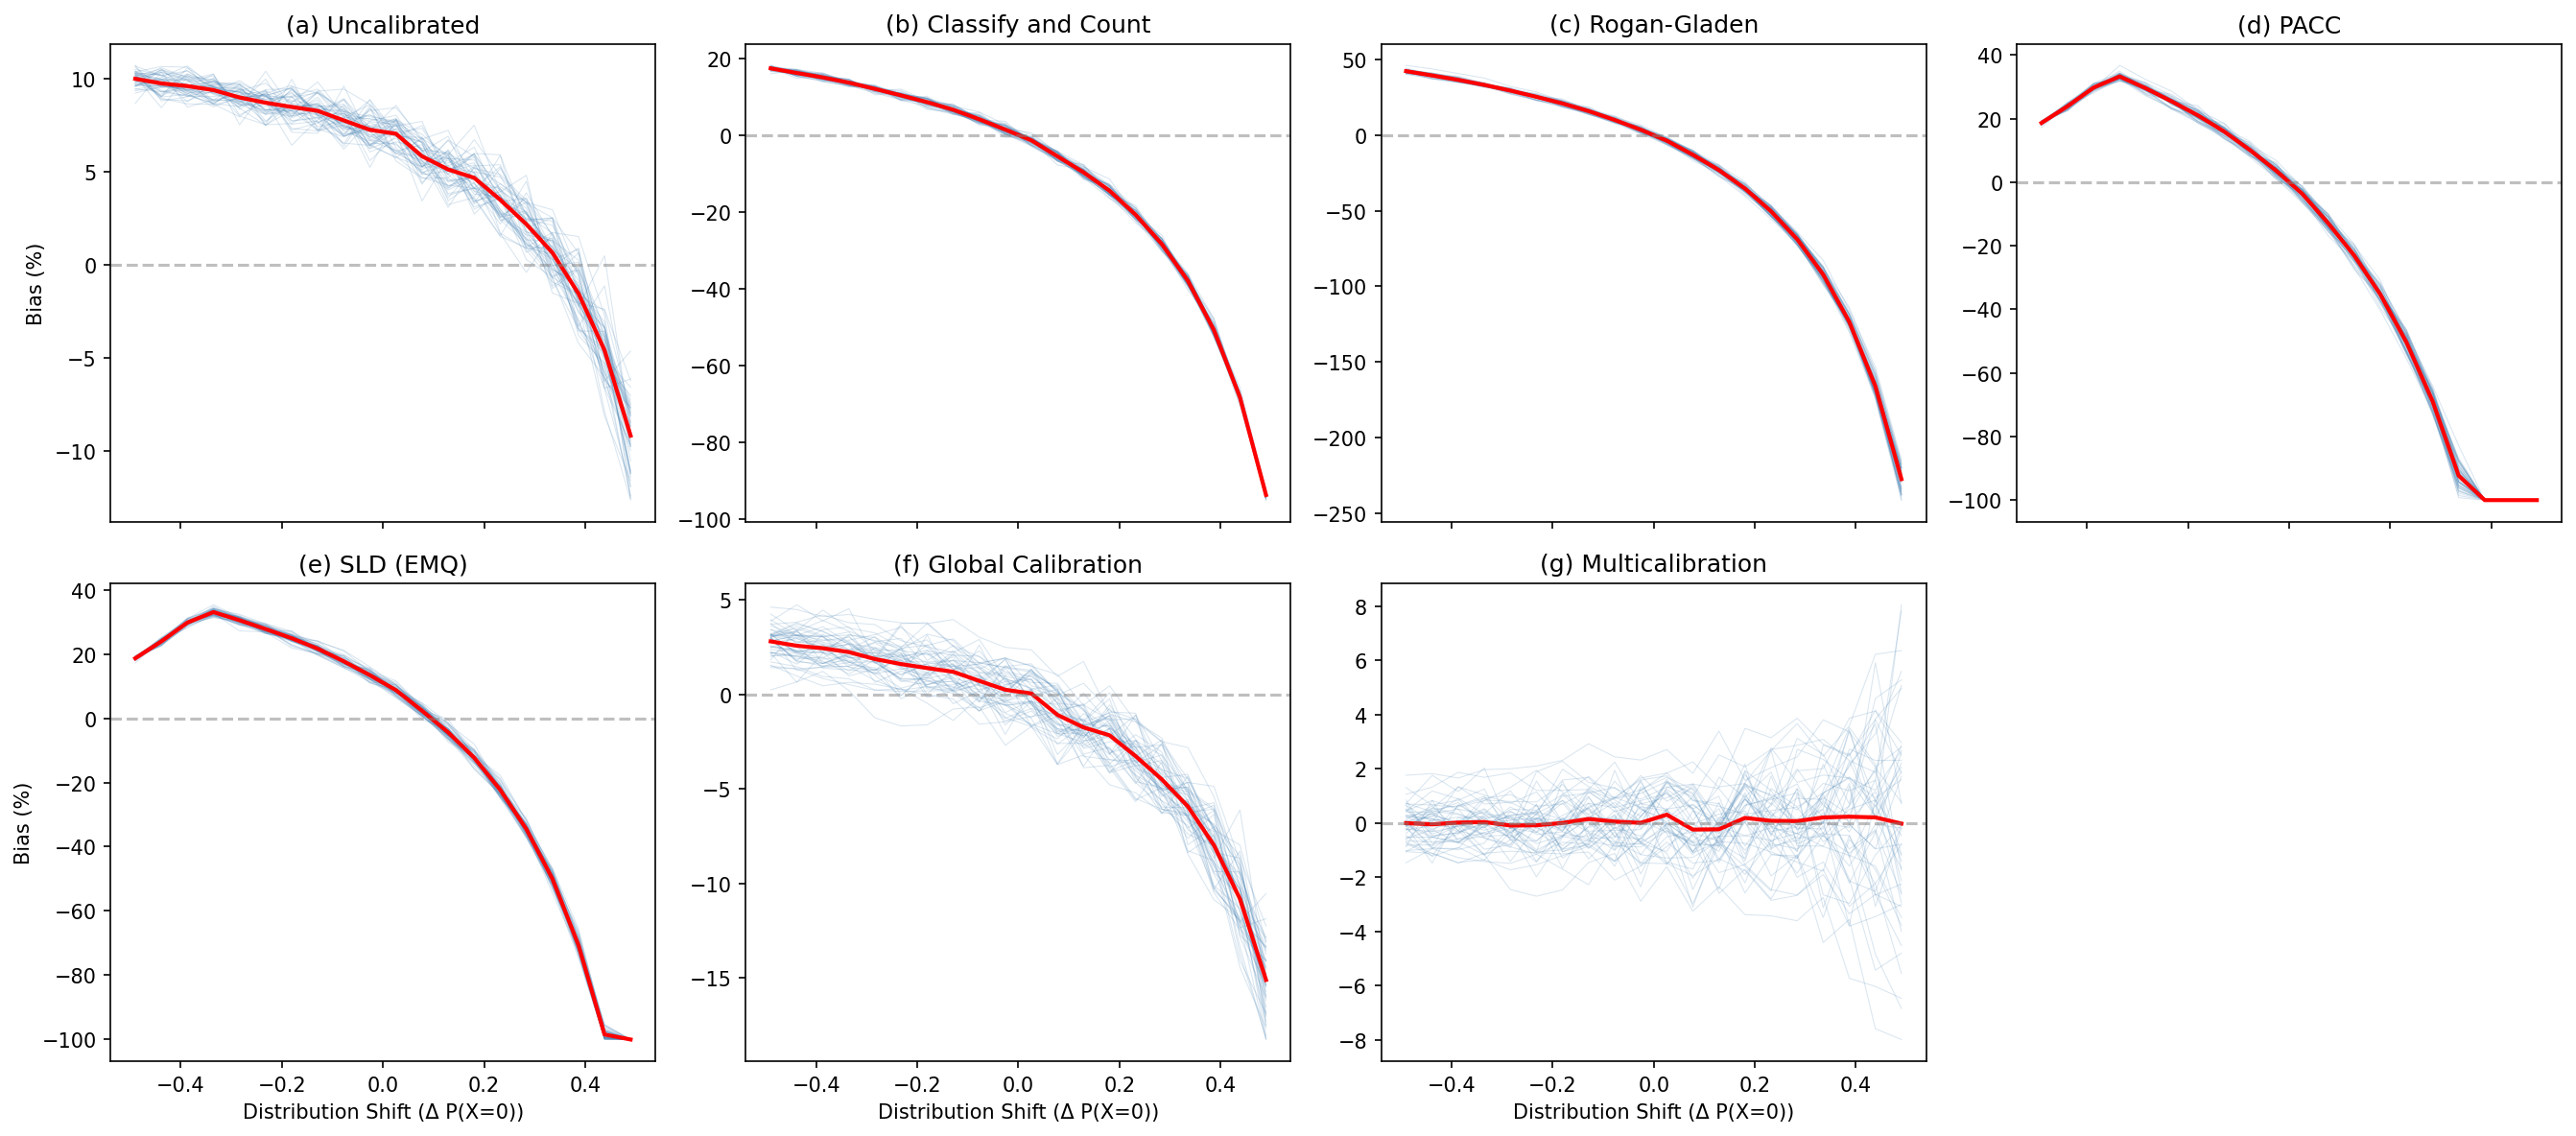

In [15]:
# Per-method bias panels (7-panel figure)
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)

panels = [
    (0, 0, bias_curves_results["all_uncalibrated"], bias_curves_results["avg_uncalibrated"], "(a) Uncalibrated"),
    (0, 1, bias_curves_results["all_cc"], bias_curves_results["avg_cc"], "(b) Classify and Count"),
    (0, 2, bias_curves_results["all_rg"], bias_curves_results["avg_rg"], "(c) Rogan-Gladen"),
    (0, 3, bias_curves_results["all_pacc"], bias_curves_results["avg_pacc"], "(d) PACC"),
    (1, 0, bias_curves_results["all_sld"], bias_curves_results["avg_sld"], "(e) SLD (EMQ)"),
    (1, 1, bias_curves_results["all_calibrated"], bias_curves_results["avg_calibrated"], "(f) Global Calibration"),
    (1, 2, bias_curves_results["all_multicalibrated"], bias_curves_results["avg_multicalibrated"], "(g) Multicalibration"),
]

deltas = bias_curves_results["deltas"]

for row, col, all_curves, avg_curve, title in panels:
    ax = axes[row, col]
    for i in range(all_curves.shape[0]):
        ax.plot(deltas, all_curves[i], color="steelblue", linewidth=0.5, alpha=0.2)
    ax.plot(deltas, avg_curve, color="red", linewidth=2)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(title)
    if col == 0:
        ax.set_ylabel("Bias (%)")
    if row == 1:
        ax.set_xlabel("Distribution Shift (Δ P(X=0))")

# Hide the empty subplot (bottom-right)
axes[1, 3].set_visible(False)

plt.tight_layout()
plt.savefig("../paper/images/figure1_simulation_bias.png", dpi=300, bbox_inches="tight")
plt.show()


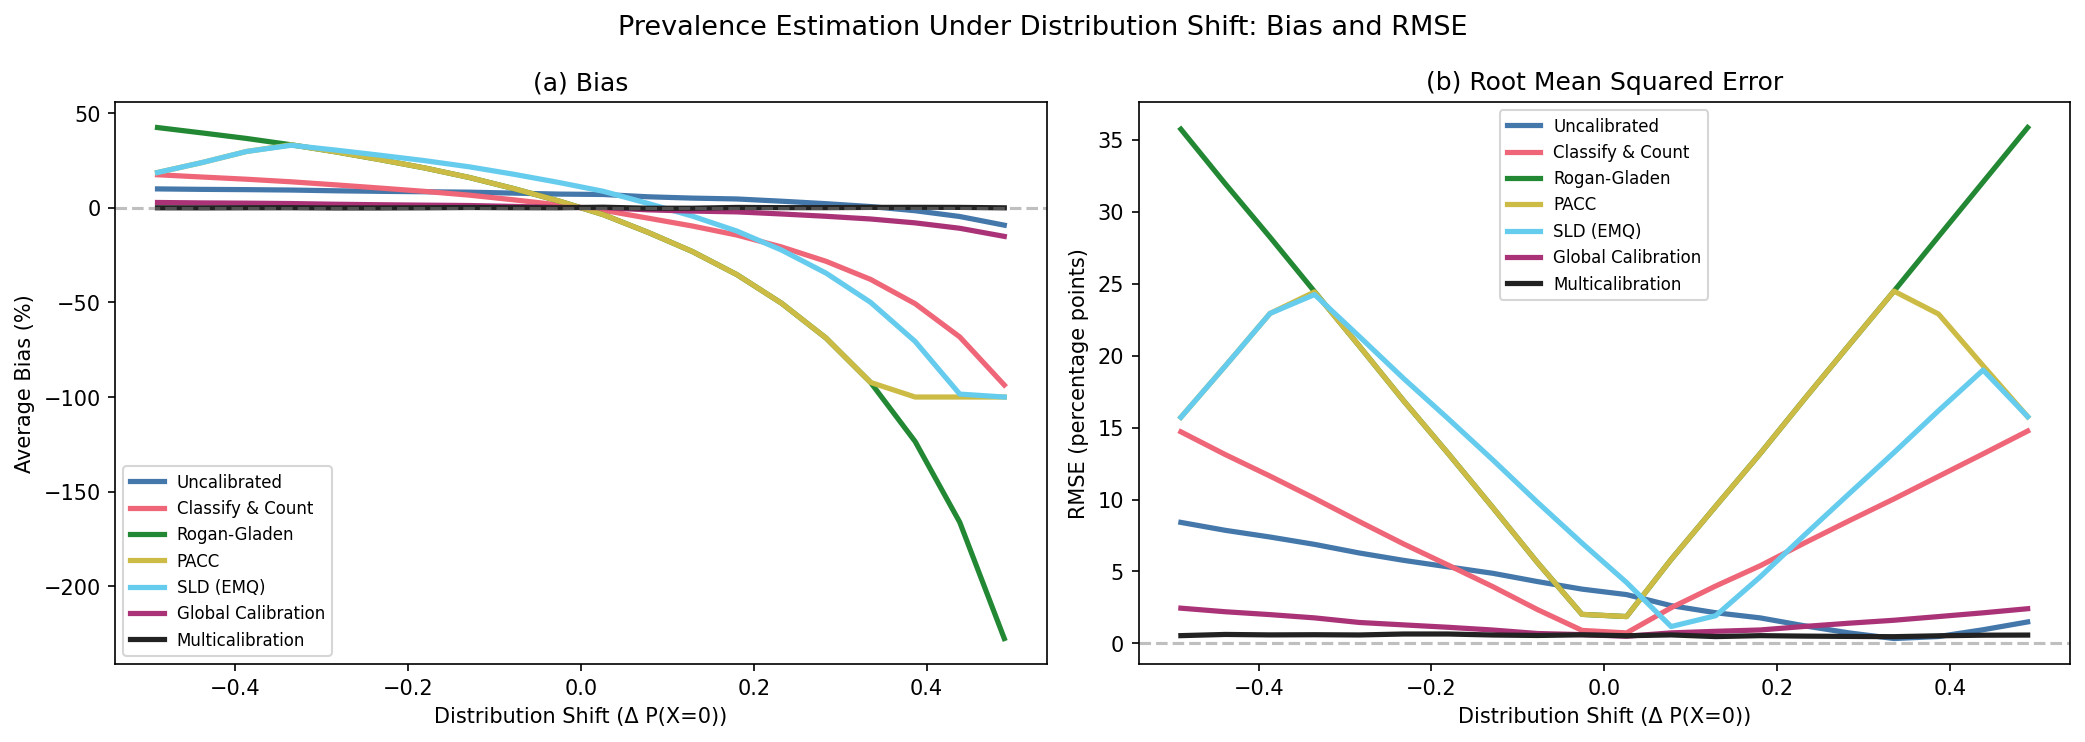

In [16]:
import sys
sys.path.insert(0, "..")
from plot_config import METHOD_COLORS

# Combined figure: Bias (left) and RMSE (right) for all methods
methods_list = [
    ("Uncalibrated", "avg_uncalibrated", "mse_uncalibrated"),
    ("Classify & Count", "avg_cc", "mse_cc"),
    ("Rogan-Gladen", "avg_rg", "mse_rg"),
    ("PACC", "avg_pacc", "mse_pacc"),
    ("SLD (EMQ)", "avg_sld", "mse_sld"),
    ("Global Calibration", "avg_calibrated", "mse_calibrated"),
    ("Multicalibration", "avg_multicalibrated", "mse_multicalibrated"),
]

deltas = bias_curves_results["deltas"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Average Bias
for name, bias_key, mse_key in methods_list:
    ax1.plot(deltas, bias_curves_results[bias_key], color=METHOD_COLORS[name], linewidth=2.5, label=name)
ax1.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax1.set_xlabel("Distribution Shift (Δ P(X=0))")
ax1.set_ylabel("Average Bias (%)")
ax1.set_title("(a) Bias")
ax1.legend(fontsize=8)

# Right panel: RMSE
for name, bias_key, mse_key in methods_list:
    rmse = np.sqrt(bias_curves_results[mse_key])
    ax2.plot(deltas, rmse, color=METHOD_COLORS[name], linewidth=2.5, label=name)
ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Distribution Shift (Δ P(X=0))")
ax2.set_ylabel("RMSE (percentage points)")
ax2.set_title("(b) Root Mean Squared Error")
ax2.legend(fontsize=8)

fig.suptitle("Prevalence Estimation Under Distribution Shift: Bias and RMSE", fontsize=13)
fig.tight_layout()
fig.savefig("../paper/images/figure_multicalibration_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
